# Introduction: Introduction and Project Objective

In this project, we ask the practical research question: Does adaptive volatility learning substantially improve predictive uncertainty in noisy, high-frequency markets, or does the additional model complexity yield minimal gains? 

To answer this question, we will use one-step-ahead probabilistic forecasting for 1-minute Bitcoin prices, based on BTC-USD candle data from Coinbase. Two models will be compared: a static Gaussian baseline with fixed volatility and a Bayesian predictive model that updates sequentially. Markets are inherently noisy, so the goal is not perfect prediction but better-calibrated uncertainty. Instead of predicting a single next price, the goal is to estimate the full predictive distribution of the next return and map that uncertainty back into a price forecast. 

In real trading or risk settings, underestimating uncertainty can lead to overconfidence, which becomes especially costly during fast market moves. A model that looks acceptable on average can still fail when volatility spikes.

Those models show a key tradeoff: Bayesian Volatility improves uncertainty but can lag during rapid market changes, highlighting a fundamental concept of stability and responsiveness in sequential modeling

The main takeaway is that Bayesian updating provides slightly better uncertainty quantification, but the gains are limited and do not address the central failure. The underlying issue is the trade-off between stability and responsiveness. But both models remain vulnerable when market conditions change unexpectedly, which reinforces the central challenge is not just accuracy, but how a model balances stability with responsiveness.

# Data and Structure: Data Description

### Data Collection and Setup

This analysis uses the Coinbase Exchange API and 1-minute BTC/USD candlestick data for 1 year. Each candle contains open, high, low, close, and volume information, providing a sequential record of market behavior at a fine time resolution. In each candle, only the closing price is used to compute returns, establishing a consistent definition of price change. 

Bitcoin was chosen for two reasons: it trades continuously, providing an environment for studying high-frequency uncertainty, and it offers 1-minute data that is noisy enough to stress-test whether adaptive volatility modeling can outperform a fixed-volatility baseline. 

This section describes the global settings used throughout the project, including the data source, predefined time window, random seed, forecast settings, and helper functions for downloading and cleaning canonical candle data.


In [1]:
# 1. Imports & Global Settings

import os
import time
from datetime import datetime, timedelta, timezone

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import math

# Reproducibility
SEED = 123
rng = np.random.default_rng(SEED)

# Fixed anchor time
ANCHOR_END_UTC_STR = "2026-02-24T00:00:00Z"
ANCHOR_END_UTC = datetime.fromisoformat(
    ANCHOR_END_UTC_STR.replace("Z", "+00:00")
)

# Data source and storage
PRODUCT = "BTC-USD"
HISTORY_DAYS = 365
GRANULARITY_S = 60  # 60 seconds = 1 minute bars

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

ANCHOR_TAG = ANCHOR_END_UTC.strftime("%Y%m%d")
CANONICAL_CSV = os.path.join(
    DATA_DIR,
    f"{PRODUCT.replace('-', '_').lower()}_{GRANULARITY_S}s_{ANCHOR_TAG}.csv"
)

COINBASE_BASE_URL = "https://api.exchange.coinbase.com"
USER_AGENT = "AdaptiveVolatilityLearning/1.0"
REQUEST_TIMEOUT_S = 20
MAX_CANDLES_PER_REQUEST = 300
RETRIES = 5
BACKOFF_S = 1.0

# Train/test split
TRAIN_FRAC = 0.80

# Forecast settings
N_SIMS = 5000
PI_LO = 0.05
PI_HI = 0.95

# Plot toggle
SHOW_PLOTS = True

# Time window
END_UTC = ANCHOR_END_UTC
START_UTC = END_UTC - timedelta(days=HISTORY_DAYS)

In [2]:
# 2. Helper Functions for Data Download and Cleaning

def iso_utc(dt: datetime) -> str:
    """Convert datetime to Coinbase ISO-8601 format (UTC, ending with 'Z')."""
    if dt.tzinfo is None:
        dt = dt.replace(tzinfo=timezone.utc)
    return dt.astimezone(timezone.utc).isoformat().replace("+00:00", "Z")


def cb_get_candles(product, start, end, granularity_s, session=None):
    """
    Coinbase Exchange REST
    Returns rows: [time, low, high, open, close, volume]
    """
    url = f"{COINBASE_BASE_URL}/products/{product}/candles"
    params = {
        "start": iso_utc(start),
        "end": iso_utc(end),
        "granularity": int(granularity_s),
    }

    # Create a session if none is provided
    if session is None:
        session = requests.Session()
        session.headers.update({"User-Agent": USER_AGENT})

    last_err = None

    for attempt in range(1, RETRIES + 1):
        try:
            r = session.get(url, params=params, timeout=REQUEST_TIMEOUT_S)
            r.raise_for_status()
            return r.json()
        except Exception as e:
            last_err = e
            time.sleep(BACKOFF_S * (2 ** (attempt - 1)))

    raise RuntimeError("Coinbase request failed after retries") from last_err


def download_candles(product, start, end, granularity_s):
    """Download candles in Coinbase-sized chunks."""
    session = requests.Session()
    session.headers.update({"User-Agent": USER_AGENT})

    chunk_seconds = MAX_CANDLES_PER_REQUEST * granularity_s
    cur = start
    frames = []

    while cur < end:
        nxt = min(end, cur + timedelta(seconds=chunk_seconds))

        data = cb_get_candles(
            product=product,
            start=cur,
            end=nxt,
            granularity_s=granularity_s,
            session=session,
        )

        if data:
            df = pd.DataFrame(
                data,
                columns=["time", "low", "high", "open", "close", "volume"],
            )
            frames.append(df)

        cur = nxt

    if not frames:
        return pd.DataFrame(columns=["time", "low", "high", "open", "close", "volume"])

    return pd.concat(frames, ignore_index=True)


def clean_candles(df):
    """Clean, Remove duplicates, and sort candle data."""
    if df.empty:
        return df.copy()

    out = df.copy()

    # numeric coercion
    out["time"] = pd.to_numeric(out["time"], errors="coerce")
    for c in ["low", "high", "open", "close", "volume"]:
        out[c] = pd.to_numeric(out[c], errors="coerce")

    # drop bad rows
    out = out.dropna(subset=["time", "close"])
    out["time"] = out["time"].astype("int64")

    # Remove duplicates + sort
    out = out.drop_duplicates(subset=["time"], keep="last")
    out = out.sort_values("time").reset_index(drop=True)

    return out



# 3. Load (or download) canonical dataset

if os.path.exists(CANONICAL_CSV):
    candles_df = pd.read_csv(CANONICAL_CSV)
    candles_df = clean_candles(candles_df)
else:
    print(f"Product: {PRODUCT}")
    print(f"Window : {START_UTC.isoformat()} → {END_UTC.isoformat()}")

    raw_df = download_candles(
        product=PRODUCT,
        start=START_UTC,
        end=END_UTC,
        granularity_s=GRANULARITY_S,
    )

    candles_df = clean_candles(raw_df)
    candles_df.to_csv(CANONICAL_CSV, index=False)

After cleaning and preprocessing, the dataset contains no missing values in the variables used for analysis.

### Example of Raw Candle Data

The data is structured as a high-frequency time series, where each observation represents a 1-minute snapshot of market activity. Each row includes:

- open: price at the start of the interval  
- high: highest price within the interval  
- low: lowest price within the interval  
- close: price at the end of the interval  
- volume: traded volume during the interval  

These features describe the price movement within each interval, forming a sequential record of market behavior over time.

### Table 1 - Raw Candle Data

In [3]:
# 4. Dataset Summary

candles_df.head()

,time,low,high,open,close,volume
0,1740355200,96266.23,96320.53,96266.23,96281.16,4.040833
1,1740355260,96281.15,96328.43,96281.15,96283.67,1.901450
2,1740355320,96214.67,96283.66,96283.66,96214.67,4.723413
3,1740355380,96196.74,96225.04,96215.32,96212.25,0.966086
4,1740355440,96212.25,96268.93,96212.25,96265.17,2.592311


# From Prices to Returns: Transformation to Log Returns

The raw candlestick closing prices are transformed into log returns, allowing the models to focus on relative changes rather than raw price levels.

The log return at time $t$ is defined as:

$$
r_t = \log\left(\frac{P_t}{P_{t-1}}\right)
$$

where $P_t$ is the closing price at time $t$.

Price series are non-stationary and change scale over time. By transforming prices into log returns, the time series becomes more stable, making its behavior more consistent and better suited for probabilistic modeling.

This transformation also creates a direct connection between the statistical model and the forecasting step. Once a predictive distribution for returns is obtained, it can be mapped back into a predictive distribution for future prices.


### Table 2 - Returns Data Sample

In [4]:
# 6. Compute Log Returns

price_df = candles_df.copy()
price_df["datetime"] = pd.to_datetime(price_df["time"], unit="s", utc=True)

price_df["log_return"] = np.log(price_df["close"] / price_df["close"].shift(1))

returns_df = price_df.dropna(subset=["log_return"]).reset_index(drop=True)

# Clean display version
display_returns_df = returns_df.copy()
display_returns_df["datetime"] = display_returns_df["datetime"].dt.strftime("%Y-%m-%d %H:%M")

display_returns_df[["datetime", "close", "log_return"]].head()

,datetime,close,log_return
0,2025-02-24 00:01,96283.67,0.000026
1,2025-02-24 00:02,96214.67,-0.000717
2,2025-02-24 00:03,96212.25,-0.000025
3,2025-02-24 00:04,96265.17,0.000550
4,2025-02-24 00:05,96321.98,0.000590


# Modeling Volatility: Data Preparation and Summary

Volatility is not constant over time. Instead, it appears in clusters, where periods of high volatility are followed by more high volatility, and periods of low volatility as well. 
This motivates the use of models that can adapt to changing uncertainty rather than assuming a fixed level of variance.


### Figure 1 - _Time Series of Log Returns_

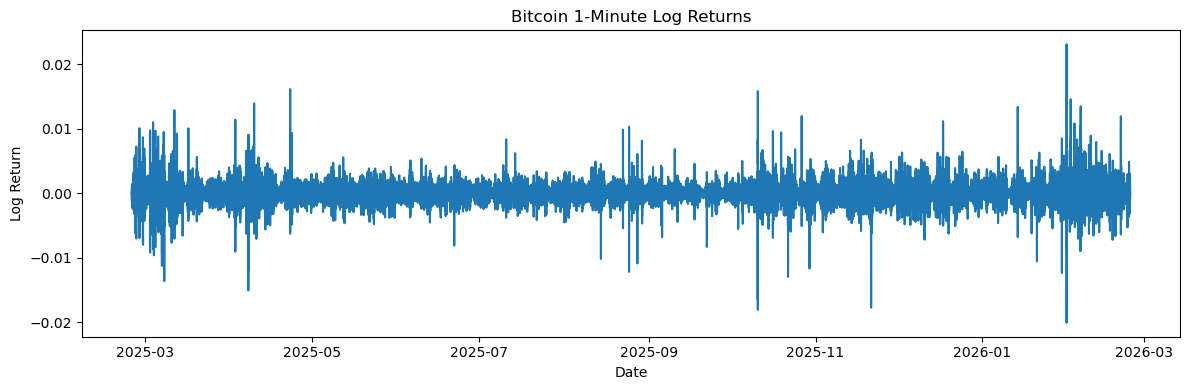

In [5]:
# 8. Log Return Time Series

if SHOW_PLOTS:
    plt.figure(figsize=(12, 4))
    plt.plot(returns_df["datetime"], returns_df["log_return"])
    plt.title("Bitcoin 1-Minute Log Returns")
    plt.xlabel("Date")
    plt.ylabel("Log Return")
    plt.tight_layout()
    plt.show()

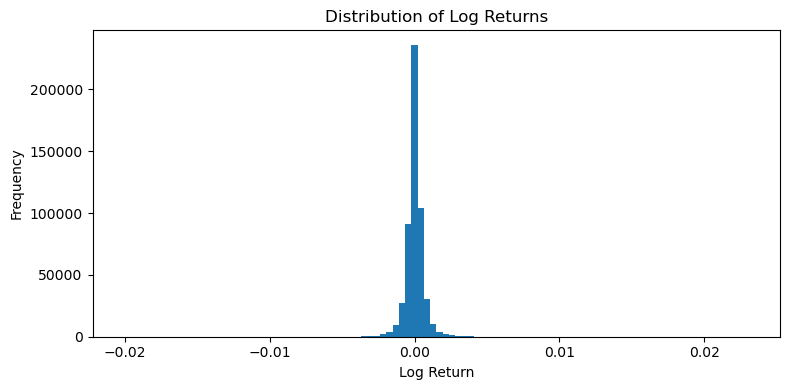

In [6]:
# 9. Histogram of Log Returns

if SHOW_PLOTS:
    plt.figure(figsize=(8, 4))
    plt.hist(returns_df["log_return"], bins=100)
    plt.title("Distribution of Log Returns")
    plt.xlabel("Log Return")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

The distribution of returns shows a high concentration of values near zero, along with a number of large positive and negative movements. This pattern is consistent with heavy-tailed behavior, where extreme events occur more frequently than expected under a normal distribution.

### Figure 2 - _Rolling Volatility Over Time_

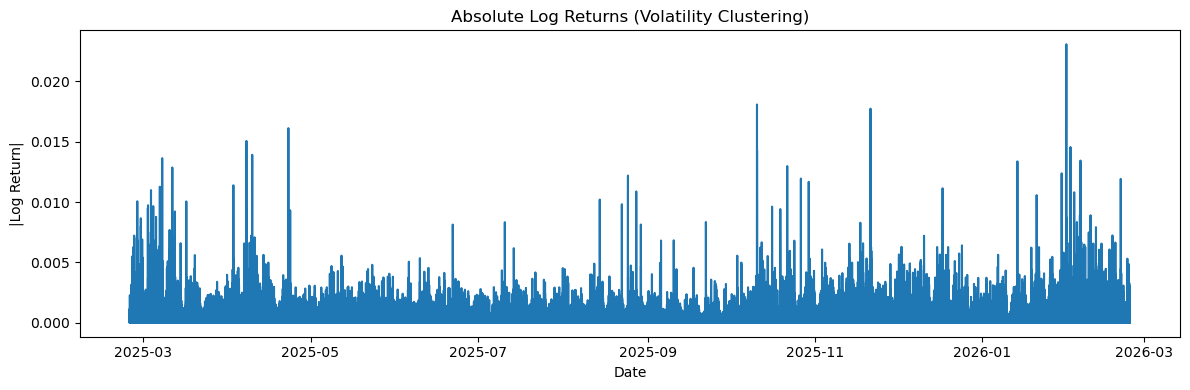

In [7]:
# 10. Volatility Clustering (Absolute Returns)

if SHOW_PLOTS:
    plt.figure(figsize=(12, 4))
    plt.plot(returns_df["datetime"], np.abs(returns_df["log_return"]))
    plt.title("Absolute Log Returns (Volatility Clustering)")
    plt.xlabel("Date")
    plt.ylabel("|Log Return|")
    plt.tight_layout()
    plt.show()

The magnitude of returns shows clear clustering behavior. Large movements tend to occur in groups, followed by periods of relatively small fluctuations. This pattern indicates that volatility is not constant over time, reinforcing the presence of volatility clustering.

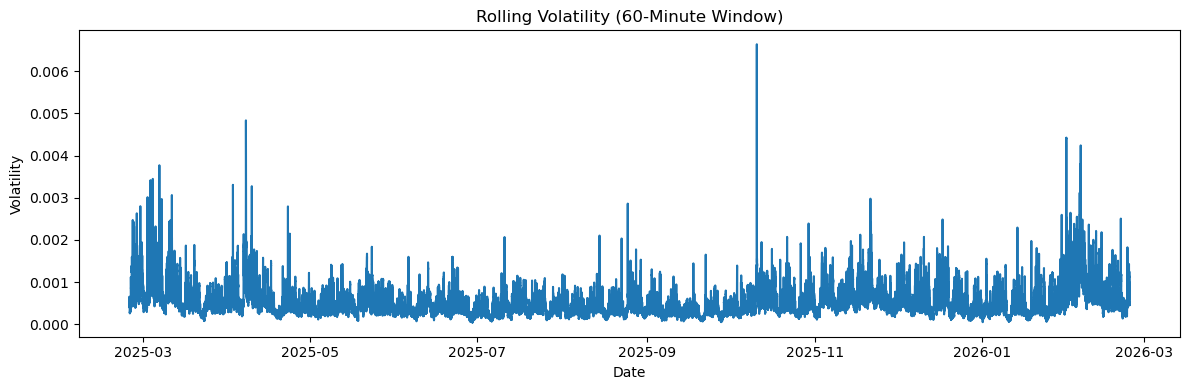

In [8]:
# 11. Rolling Volatility

window = 60  # 60 minutes

returns_df["rolling_vol"] = returns_df["log_return"].rolling(window).std()

if SHOW_PLOTS:
    plt.figure(figsize=(12, 4))
    plt.plot(returns_df["datetime"], returns_df["rolling_vol"])
    plt.title("Rolling Volatility (60-Minute Window)")
    plt.xlabel("Date")
    plt.ylabel("Volatility")
    plt.tight_layout()
    plt.show()

Financial markets do not behave consistently over time. Periods of calm can quickly shift into periods of high volatility, making uncertainty constantly change.

Models that assume a fixed level of variability (constant variance) might fail to capture how markets behave. This motivates the use of probabilistic models that can adapt to changing levels of uncertainty over time.

# Forecasting Setup: Probabilistic Modeling of Returns

### Table 3 - Return Summary Statistics

In [9]:
# Compute summary statistics
summary = returns_df["log_return"].describe()

# Build clean table
summary_df = pd.DataFrame({
    "Statistic": ["Count", "Mean", "Std Dev", "Min", "25%", "Median", "75%", "Max"],
    "Value": [
        int(summary["count"]),
        summary["mean"],
        summary["std"],
        summary["min"],
        summary["25%"],
        summary["50%"],
        summary["75%"],
        summary["max"],
    ]
})

# Format values (no scientific notation, readable precision)
def format_value(x):
    if isinstance(x, (int, np.integer)):
        return f"{x:,}"
    elif isinstance(x, (float, np.floating)):
        return f"{x:.6f}"
    return x

summary_df["Value"] = summary_df["Value"].apply(format_value)

summary_df

,Statistic,Value
0,Count,525217.000000
1,Mean,-0.000001
2,Std Dev,0.000636
3,Min,-0.020089
4,25%,-0.000250
5,Median,0.000000
6,75%,0.000251
7,Max,0.023069


The mean is essentially zero while the variability is small but still present. The data shows large swings, which indicates that volatile change may occur more often than the model would predict  

This is why we move toward models that can adapt to both stable and more volatile periods. 

We considered two probabilistic forecasting approaches to model the distribution of future returns. A Static Gaussian Model and a Bayesian predictive model. 

The intention is for both models to estimate the full distribution of future returns rather than to produce a single point prediction, which allows us to quantify uncertainty and capture the range of possible outcomes 



### Static Gaussian Model

As a baseline, we assume that returns follow a normal distribution:

$$
r_t \sim \mathcal{N}(\mu, \sigma^2)
$$

where $\mu$ is the mean return and $\sigma^2$ is the variance. These parameters are estimated from historical data and remain fixed over time.

This is our baseline model due to it being simple and easy to work with. It does assume that volatility is constant, so it can't respond when market condition change. 



### Bayesian Predictive Model

To address the constant volatility, we use a Bayesian approach that allows model parameters to update over time. Instead of treating volatility as a constant, we treat it as uncertain and update our beliefs as new data becomes available.

Under this model, parameter uncertainty is incorporated directly into the predictive distribution. As a result, the predictive distribution for the next return takes the form of a Student-t distribution:

$$
r_{t+1} \mid \text{data} \sim t_{\nu}(m_n, s_n)
$$

This formula reflects both observed data and parameter uncertainty, allowing the model to adapt to changing volatility and better capture the variability observed in financial markets.


# Evaluation Design: Model Specification and Parameter Estimation

We use the training data to estimate the average and variability, keeping them fixed during forecasting. This gives us a baseline to compare against the adaptive Bayesian Model. 

### Table 4 - Static Model Parameter Estimates

In [10]:
# Estimate parameters from log returns
mu_hat = returns_df["log_return"].mean()
sigma_hat = returns_df["log_return"].std()

pd.DataFrame({
    "Parameter": ["Mean (μ)", "Std Dev (σ)"],
    "Value": [mu_hat, sigma_hat]
}).round(6)

,Parameter,Value
0,Mean (μ),-0.000001
1,Std Dev (σ),0.000636


# Results: Forecasting Pipeline

Monte Carlo simulation is used in the forecasting step to generate a range of possible next-step returns rather than a single value. Those simulated returns are then converted into a price samples. Median forecast and the 90% prediction interval summarize the final one-step-ahead output. 


### Monte Carlo Forecast (Single-Step Example)

The following example shows how a one-step-ahead predictive distribution is generated. Instead of producing a single forecast, the model simulates many possible outcomes from the predictive distribution.

In [11]:
# 13. Monte Carlo Forecast (Formatted Table)

last_return = returns_df["log_return"].iloc[-1]

# Simulate returns (Gaussian baseline)
simulated_returns = rng.normal(mu_hat, sigma_hat, size=N_SIMS)

# Summary statistics
forecast_median = float(np.median(simulated_returns))
forecast_lo = float(np.quantile(simulated_returns, PI_LO))
forecast_hi = float(np.quantile(simulated_returns, PI_HI))

# Build table
forecast_summary_df = pd.DataFrame({
    "Metric": [
        "Median Forecast",
        "Lower Bound (90% PI)",
        "Upper Bound (90% PI)"
    ],
    "Value": [
        forecast_median,
        forecast_lo,
        forecast_hi
    ]
})

# Format nicely
forecast_summary_df["Value"] = forecast_summary_df["Value"].apply(lambda x: f"{x:.6f}")

forecast_summary_df

,Metric,Value
0,Median Forecast,0.000004
1,Lower Bound (90% PI),-0.001051
2,Upper Bound (90% PI),0.001048


The median of the simulated returns provides a central estimate, while the lower and upper quantiles define a 90% prediction interval. Together, these summarize both expected behavior and forecast uncertainty.

### Figure 3 - _Simulated Predictive Distribution of Returns_

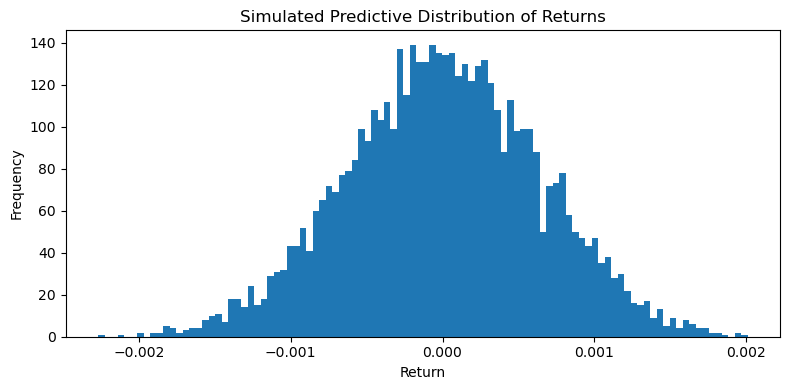

In [12]:
# Predictive Distribution Plot

if SHOW_PLOTS:
    plt.figure(figsize=(8, 4))
    plt.hist(simulated_returns, bins=100)
    plt.title("Simulated Predictive Distribution of Returns")
    plt.xlabel("Return")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

The simulated distribution shows the range of possible one-step-ahead returns under the model. Most values are concentrated near the center, while the spread reflects uncertainty. The tails represent less likely but still possible outcomes, creating a more complete view of risk than a single point forecast.

# Stress Regime Analysis: Walk-Forward Evaluation Design

To evaluate each model's performance, we use a time-based train/test split combined with a walk-forward evaluation. A walk-forward evaluation makes the prediction in order, using only past information at each step, and moves forward through time. This approach avoids using future data and mimics how a real forecasting system operates.
This section shows how the data is split, how the models are initialized, and how inputs are prepared before scoring begins.

### Train/Test Split


### Table 5 - Train/Test Split Summary

In [13]:
# Ensure datetime is proper and sorted
returns_df["datetime"] = pd.to_datetime(returns_df["datetime"])
returns_df = returns_df.sort_values("datetime")

total_obs = len(returns_df)
split_idx = int(0.8 * total_obs)

train_df = returns_df.iloc[:split_idx]
test_df = returns_df.iloc[split_idx:]

summary_split_df = pd.DataFrame({
    "Metric": [
        "Total Observations",
        "Training Observations",
        "Test Observations",
        "Training Start",
        "Training End",
        "Test Start",
        "Test End"
    ],
    "Value": [
        f"{total_obs:,}",
        f"{len(train_df):,}",
        f"{len(test_df):,}",
        train_df["datetime"].min().strftime("%Y-%m-%d %H:%M"),
        train_df["datetime"].max().strftime("%Y-%m-%d %H:%M"),
        test_df["datetime"].min().strftime("%Y-%m-%d %H:%M"),
        test_df["datetime"].max().strftime("%Y-%m-%d %H:%M")
    ]
})

summary_split_df

,Metric,Value
0,Total Observations,"525,217"
1,Training Observations,"420,173"
2,Test Observations,"105,044"
3,Training Start,2025-02-24 00:01
4,Training End,2025-12-13 01:00
5,Test Start,2025-12-13 01:01
6,Test End,2026-02-24 00:00


### Model Initialization

The static Gaussian model is fit once on the training data and remains fixed throughout the evaluation period.

The Bayesian model is initialized using the training data and updated sequentially as new observations become available during the test period.

### Table 6 - Model Initialization

In [14]:
# Model Initialization (train-only, using returns_df)

mu_hat = train_df["log_return"].mean()
sigma_hat = train_df["log_return"].std()

n = len(train_df)
nu = n  # placeholder/simple proxy unless you use a different Bayesian setup

param_init_df = pd.DataFrame({
    "Model": ["Static Gaussian", "Bayesian Predictive"],
    "Parameter": ["Mean / Std Dev", "ν / μ / σ"],
    "Value": [
        f"μ={mu_hat:.6f}, σ={sigma_hat:.6f}",
        f"ν={nu:,.0f}, μ={mu_hat:.6f}, σ={sigma_hat:.6f}"
    ]
})

param_init_df

,Model,Parameter,Value
0,Static Gaussian,Mean / Std Dev,"μ=-0.000000, σ=0.000611"
1,Bayesian Predictive,ν / μ / σ,"ν=420,173, μ=-0.000000, σ=0.000611"


### Table 7 - Model Input Structure

In [15]:
# 14A. Build Model-Ready DataFrame from returns_df

model_df = returns_df[["datetime", "close", "log_return"]].copy()

model_df = model_df.rename(columns={
    "close": "S_t",
    "log_return": "r_t"
})

model_df["S_tm1"] = model_df["S_t"].shift(1)

model_df = model_df.dropna(subset=["S_tm1", "r_t"]).copy()

model_df = model_df.set_index("datetime").sort_index()

# Create display-friendly version
display_model_df = model_df.copy()

# Clean datetime format
display_model_df.index = display_model_df.index.strftime("%Y-%m-%d %H:%M")

# Reorder columns for readability
display_model_df = display_model_df[["S_tm1", "S_t", "r_t"]]

# Round values for presentation
display_model_df["S_tm1"] = display_model_df["S_tm1"].round(2)
display_model_df["S_t"] = display_model_df["S_t"].round(2)
display_model_df["r_t"] = display_model_df["r_t"].round(6)

display_model_df.head()

,S_tm1,S_t,r_t
datetime,,,
2025-02-24 00:02,96283.67,96214.67,-0.000717
2025-02-24 00:03,96214.67,96212.25,-0.000025
2025-02-24 00:04,96212.25,96265.17,0.000550
2025-02-24 00:05,96265.17,96321.98,0.000590
2025-02-24 00:06,96321.98,96341.23,0.000200


In [16]:
# 14C. Static Gaussian Model Definition

class StaticSigmaModel:
    def __init__(self):
        self.mu_ = None
        self.sigma_ = None

    def fit(self, r_train):
        r = np.asarray(r_train, dtype=float)
        if r.size < 2:
            raise ValueError("Need at least 2 returns to fit StaticSigmaModel.")
        self.mu_ = float(np.mean(r))
        self.sigma_ = float(np.std(r, ddof=1))

    def params_now(self):
        if self.mu_ is None or self.sigma_ is None:
            raise RuntimeError("StaticSigmaModel not fit.")
        return self.mu_, self.sigma_

    def update(self, r_t):
        # Static: no update
        return

In [17]:
# 14D. Bayesian NIG Student-t Model Definition

class BayesianNIGStudentT:
    def __init__(self, mu0, kappa0, alpha0, beta0):
        if kappa0 <= 0:
            raise ValueError("kappa0 must be > 0.")
        if alpha0 <= 0:
            raise ValueError("alpha0 must be > 0.")
        if beta0 <= 0:
            raise ValueError("beta0 must be > 0.")

        self.mu0 = float(mu0)
        self.kappa0 = float(kappa0)
        self.alpha0 = float(alpha0)
        self.beta0 = float(beta0)

        self.n = 0
        self.sum_r = 0.0
        self.sum_r2 = 0.0

    def update(self, r_t):
        r = float(r_t)
        self.n += 1
        self.sum_r += r
        self.sum_r2 += r * r

    def posterior_params(self):
        # Returns (mu_n, kappa_n, alpha_n, beta_n)
        n = self.n
        if n == 0:
            return self.mu0, self.kappa0, self.alpha0, self.beta0

        r_bar = self.sum_r / n
        k_n = self.kappa0 + n
        mu_n = (self.kappa0 * self.mu0 + n * r_bar) / k_n
        a_n = self.alpha0 + 0.5 * n

        sse = max(self.sum_r2 - n * (r_bar * r_bar), 0.0)
        shrink = (self.kappa0 * n / (2.0 * k_n)) * ((r_bar - self.mu0) ** 2)
        b_n = self.beta0 + 0.5 * sse + shrink

        return float(mu_n), float(k_n), float(a_n), float(b_n)

    def predictive_params(self):
        # Returns (nu, loc, scale)
        mu_n, k_n, a_n, b_n = self.posterior_params()
        nu = 2.0 * a_n
        scale2 = b_n * (k_n + 1.0) / (a_n * k_n)
        scale = math.sqrt(max(scale2, 1e-18))
        return float(nu), float(mu_n), float(scale)

In [18]:
# 14D. Initialize Both Models Using Train Only

# Build model-ready dataframe first
model_df = returns_df[["datetime", "close", "log_return"]].copy()
model_df = model_df.rename(columns={"close": "S_t", "log_return": "r_t"})
model_df["S_tm1"] = model_df["S_t"].shift(1)
model_df = model_df.dropna(subset=["S_tm1", "r_t"]).copy()
model_df = model_df.set_index("datetime").sort_index()

# Time-based split
n_total = len(model_df)
split_idx = int(n_total * TRAIN_FRAC)

train_df = model_df.iloc[:split_idx].copy()
test_df = model_df.iloc[split_idx:].copy()

r_train = train_df["r_t"].to_numpy(dtype=float)

# Static baseline
static_model = StaticSigmaModel()
static_model.fit(r_train)

# Bayesian NIG prior (simple, defensible)
mu0 = float(np.mean(r_train))
var_train = float(np.var(r_train, ddof=1))

kappa0 = 1.0
alpha0 = 5.0
beta0 = max((alpha0 - 1.0) * var_train, 1e-18)

bayes_model = BayesianNIGStudentT(
    mu0=mu0,
    kappa0=kappa0,
    alpha0=alpha0,
    beta0=beta0
)

# Warm-start Bayes with training returns
for rr in r_train:
    bayes_model.update(rr)


In [19]:
# 14E. Forecast Helpers (One-step: RETURNS -> PRICE)

def sample_returns_static(mu, sigma, n_sims, rng):
    """Static baseline: r ~ Normal(mu, sigma^2)."""
    return rng.normal(loc=float(mu), scale=float(sigma), size=int(n_sims))


def sample_returns_student_t(nu, loc, scale, n_sims, rng):
    """Bayesian predictive: r ~ Student-t(nu, loc, scale)."""
    z = rng.standard_t(df=float(nu), size=int(n_sims))
    return float(loc) + float(scale) * z


def returns_to_price_samples(S_tm1, r_samps):
    """Map return samples to price samples: S_t = S_{t-1} * exp(r_t)."""
    S_prev = float(S_tm1)
    return S_prev * np.exp(np.asarray(r_samps, dtype=float))


def prediction_interval(samples, lo=PI_LO, hi=PI_HI):
    """(lo, hi) quantile interval from samples."""
    s = np.asarray(samples, dtype=float)
    return float(np.quantile(s, lo)), float(np.quantile(s, hi))


def forecast_one_step(S_tm1, model_name, static_model, bayes_model, n_sims=N_SIMS, rng=rng):
    """
    Unified one-step forecast:
      1) sample returns from model predictive
      2) map to price samples
      3) summarize by median + prediction interval
    """
    S_tm1 = float(S_tm1)
    if S_tm1 <= 0 or not np.isfinite(S_tm1):
        raise ValueError("S_tm1 must be a positive finite price.")

    model_key = model_name.strip().lower()

    if model_key == "static":
        mu, sigma = static_model.params_now()
        r_samps = sample_returns_static(mu, sigma, n_sims, rng)
        meta = {"model": "static", "mu": float(mu), "sigma": float(sigma)}

    elif model_key == "bayes":
        nu, loc, scale = bayes_model.predictive_params()
        r_samps = sample_returns_student_t(nu, loc, scale, n_sims, rng)
        meta = {"model": "bayes", "nu": float(nu), "loc": float(loc), "scale": float(scale)}

    else:
        raise ValueError("model_name must be 'static' or 'bayes'.")

    S_samps = returns_to_price_samples(S_tm1, r_samps)

    return {
        "median": float(np.median(S_samps)),
        "pi_low": float(np.quantile(S_samps, PI_LO)),
        "pi_high": float(np.quantile(S_samps, PI_HI)),
        "meta": meta,
        "r_samples": r_samps,
        "S_samples": S_samps,
    }

In [20]:
# 14H. Scoring Helpers

def normal_logpdf(x, mu, sigma):
    """Log pdf of Normal(mu, sigma^2) at x."""
    sigma = float(max(sigma, 1e-12))
    z = (float(x) - float(mu)) / sigma
    return float(-0.5 * (math.log(2.0 * math.pi) + 2.0 * math.log(sigma) + z * z))


def student_t_logpdf(x, nu, loc, scale):
    """Log pdf of Student-t(nu, loc, scale) at x (no external deps)."""
    nu = float(nu)
    loc = float(loc)
    scale = float(max(scale, 1e-12))
    z = (float(x) - loc) / scale
    logC = math.lgamma((nu + 1.0) / 2.0) - (
        0.5 * math.log(nu * math.pi) + math.lgamma(nu / 2.0)
    )
    return float(
        logC - math.log(scale) - ((nu + 1.0) / 2.0) * math.log(1.0 + (z * z) / nu)
    )


def crps_from_samples(y, samples):
    """
    CRPS from samples:
      CRPS(F,y)=E|X-y| - 0.5 E|X-X'|
    O(n log n) using sorted sample identity.
    """
    x = np.asarray(samples, dtype=float)
    n = x.size
    if n == 0:
        return float("nan")

    term1 = float(np.mean(np.abs(x - float(y))))

    xs = np.sort(x)
    idx = np.arange(1, n + 1, dtype=float)
    total_pairwise = float(np.sum((2.0 * idx - n - 1.0) * xs))
    term2 = (2.0 / (n * n)) * total_pairwise

    return float(term1 - 0.5 * term2)

In [21]:
# 14I. Walk-Forward Evaluation Function

def run_walkforward(test_df, static_model, bayes_model, n_sims=N_SIMS, rng=rng):
    """
    For each test step:
      - forecast S_t using S_{t-1}
      - score: coverage, width, CRPS (price samples), log score (return pdf), abs error
      - update Bayes after scoring
    """
    rows = []

    for dt, row in test_df.iterrows():
        S_tm1 = float(row["S_tm1"])
        S_t = float(row["S_t"])
        r_t = float(row["r_t"])

        # ---- Static ----
        f_s = forecast_one_step(
            S_tm1, "static", static_model, bayes_model, n_sims=n_sims, rng=rng
        )
        lo_s, hi_s = float(f_s["pi_low"]), float(f_s["pi_high"])
        med_s = float(f_s["median"])

        mu_s, sig_s = static_model.params_now()

        # ---- Bayes ----
        f_b = forecast_one_step(
            S_tm1, "bayes", static_model, bayes_model, n_sims=n_sims, rng=rng
        )
        lo_b, hi_b = float(f_b["pi_low"]), float(f_b["pi_high"])
        med_b = float(f_b["median"])

        nu_b = float(f_b["meta"]["nu"])
        loc_b = float(f_b["meta"]["loc"])
        scale_b = float(f_b["meta"]["scale"])

        rows.append({
            "dt": dt,
            "S_tm1": S_tm1,
            "S_t": S_t,
            "r_t": r_t,

            "pred_median_static": med_s,
            "pi_low_static": lo_s,
            "pi_high_static": hi_s,
            "hit_static": int(lo_s <= S_t <= hi_s),
            "width_static": float(hi_s - lo_s),
            "crps_static": crps_from_samples(S_t, f_s["S_samples"]),
            "logscore_static": normal_logpdf(r_t, mu_s, sig_s),
            "abs_error_static": float(abs(S_t - med_s)),

            "pred_median_bayes": med_b,
            "pi_low_bayes": lo_b,
            "pi_high_bayes": hi_b,
            "hit_bayes": int(lo_b <= S_t <= hi_b),
            "width_bayes": float(hi_b - lo_b),
            "crps_bayes": crps_from_samples(S_t, f_b["S_samples"]),
            "logscore_bayes": student_t_logpdf(r_t, nu_b, loc_b, scale_b),
            "abs_error_bayes": float(abs(S_t - med_b)),
        })

        # Update AFTER scoring
        bayes_model.update(r_t)

    return pd.DataFrame(rows).set_index("dt")

In [22]:
# 14J. Run Walk-Forward Evaluation

results_df = run_walkforward(
    test_df=test_df,
    static_model=static_model,
    bayes_model=bayes_model,
    n_sims=N_SIMS,
    rng=rng,
)



# Conclusion: Results

We compare both models with unseen data, using walk-forward evaluation. We focus on how well each model captures uncertainty using metrics like calibration, interval width, log score, CPRS, and median absolute error. 
Our main question is simple. Does the adaptive model give a better, more realistic view of uncertainty, especially when the market shifts? 



### Table 8 - Walk-Forward Performance

In [23]:
# Overall Walk-Forward Test Performance

results_summary_df = pd.DataFrame({
    "Metric": [
        "Coverage (90%)",
        "Average Interval Width",
        "Median Absolute Error (MAE)",
        "Average Log Score",
        "Average CRPS"
    ],
    "Static Gaussian": [
        results_df["hit_static"].mean(),
        results_df["width_static"].mean(),
        results_df["abs_error_static"].median(),
        results_df["logscore_static"].mean(),
        results_df["crps_static"].mean()
    ],
    "Bayesian Predictive": [
        results_df["hit_bayes"].mean(),
        results_df["width_bayes"].mean(),
        results_df["abs_error_bayes"].median(),
        results_df["logscore_bayes"].mean(),
        results_df["crps_bayes"].mean()
    ]
})

# Create a display-only copy so formatting doesn't fight numeric dtypes
results_display_df = results_summary_df.copy()

coverage_mask = results_display_df["Metric"] == "Coverage (90%)"

for col in ["Static Gaussian", "Bayesian Predictive"]:
    results_display_df[col] = results_display_df[col].astype(object)
    results_display_df.loc[coverage_mask, col] = (
        results_summary_df.loc[coverage_mask, col]
        .map(lambda x: f"{100*x:.2f}%")
    )
    results_display_df.loc[~coverage_mask, col] = (
        results_summary_df.loc[~coverage_mask, col]
        .map(lambda x: f"{x:.4f}")
    )

results_display_df

,Metric,Static Gaussian,Bayesian Predictive
0,Coverage (90%),89.65%,89.81%
1,Average Interval Width,167.2950,167.4064
2,Median Absolute Error (MAE),21.3052,21.2933
3,Average Log Score,5.7746,5.7827
4,Average CRPS,27.9924,27.9633


The main metrics we use are:

- **Mean CRPS**: overall probabilistic accuracy, lower is better  
- **Coverage (90%)**: how often the true price falls inside the 90% prediction interval  
- **Median Absolute Error**: the typical error of the median forecast  
- **Average Log Score**: how much probability the model assigns to what happened  

## Continuous Ranked Probability Score (CRPS)

CRPS measures how good the entire predicted distribution is, not just a single point estimate. It rewards models that are both accurate and assign probability to the right areas.

In practice, we approximate it using Monte Carlo samples from the predictive distribution.

In [24]:
# 15A. Results Summary Table

summary_table = pd.DataFrame({
    "Model": ["Static Gaussian", "Bayesian Predictive"],
    "Mean CRPS": [
        results_df["crps_static"].mean(),
        results_df["crps_bayes"].mean(),
    ],
    "Coverage (90%)": [
        results_df["hit_static"].mean(),
        results_df["hit_bayes"].mean(),
    ],
    "Median Abs Error": [
        results_df["abs_error_static"].median(),
        results_df["abs_error_bayes"].median(),
    ],
})

# 15B. Rounded Results Table

summary_table_rounded = summary_table.copy()
summary_table_rounded["Mean CRPS"] = summary_table_rounded["Mean CRPS"].round(2)
summary_table_rounded["Coverage (90%)"] = summary_table_rounded["Coverage (90%)"].round(3)
summary_table_rounded["Median Abs Error"] = summary_table_rounded["Median Abs Error"].round(2)

summary_table_rounded

,Model,Mean CRPS,Coverage (90%),Median Abs Error
0,Static Gaussian,27.99,0.896,21.31
1,Bayesian Predictive,27.96,0.898,21.29


Across the full test set, the two models perform almost identically. The Bayesian model shows slight improvements in probabilistic metrics like CRPS and coverage, but the gains are marginal, and point accuracy remains essentially unchanged. 

These differences are small. The Bayesian approach provides slightly better estimates of uncertainty. However, it does not meaningfully improve overall predictive performance. Based on the performance, in this setting, adaptive volatility modeling offers limited practical benefits. 

The complexity leads to marginal improvements in uncertainty but does not change the broader forecasting outcome. In a high-noise cryptocurrency environment, much of the next-step variation remains difficult to predict, which limits how much improvement any model can achieve at these intervals. 

## Limitations
- The assumption of the model is that over short time windows, the returns are normally distributed. If behavior changes extremely quickly or exhibits more heavy-tailed behavior, this assumption can break down. 

- Rather than modeling things like volatility clustering or regime shifts, the volatility is only updated using Bayesian rules.

- The Bayesian approach may not update fast enough during sudden volatility spikes, which can underestimate uncertainty temporarily.

Given these known limitations, it captures the underlying behavior but still simplifies several aspects of how actual financial markets operate. 


## Stress Period Analysis

Full-sample averages can mask where the model actually fails, especially during more volatile periods. 

To fully review our models, we break out performance during high-volatile periods and evaluate each model separately. 

The intention behind this diagnostic is that a model can look acceptable on average but can be overconfident when market conditions are unstable.

This answer is a more direct research question. Not if the Bayesian update improves overall, but if it can predict correctly when the market becomes volatile. 


### Table 9 - Performance by Market Regime

In [25]:
# 16A. Rolling Volatility (used for stress regime)

ROLLING_VOL_WINDOW_MIN = 60  # 60-minute rolling window

# Use returns_df (must have datetime + log_return)
roll_vol = (
    returns_df
    .set_index("datetime")["log_return"]
    .rolling(ROLLING_VOL_WINDOW_MIN)
    .std()
)


In [26]:
# 16B. Stress Regime Analysis — Quantile-Based High-Volatility Slice

STRESS_Q = 0.90

vol_df = pd.DataFrame({"roll_vol": roll_vol}).reindex(results_df.index)

stress_thresh = float(vol_df["roll_vol"].quantile(STRESS_Q))
vol_df["is_stress"] = vol_df["roll_vol"] >= stress_thresh

results_stress = results_df.join(vol_df, how="left")

stress_df = results_stress[results_stress["is_stress"]].copy()
calm_df = results_stress[~results_stress["is_stress"]].copy()

def summarize_subset(df: pd.DataFrame, label: str) -> pd.DataFrame:
    rows = []
    for model in ["static", "bayes"]:
        rows.append({
            "subset": label,
            "model": model,
            "n": int(len(df)),
            "coverage_90": float(df[f"hit_{model}"].mean()),
            "avg_interval_width": float(df[f"width_{model}"].mean()),
            "mean_CRPS": float(df[f"crps_{model}"].mean()),
            "mean_log_score": float(df[f"logscore_{model}"].mean()),
            "median_abs_error": float(df[f"abs_error_{model}"].median()),
        })
    return pd.DataFrame(rows)

stress_summary_df = pd.concat(
    [
        summarize_subset(results_stress.dropna(subset=["is_stress"]), "full"),
        summarize_subset(stress_df, "stress"),
        summarize_subset(calm_df, "calm"),
    ],
    ignore_index=True
)

stress_summary_df = stress_summary_df.sort_values(
    ["subset", "mean_CRPS"],
    ascending=[True, True]
).reset_index(drop=True)

stress_summary_df["coverage_90"] = stress_summary_df["coverage_90"].round(3)
stress_summary_df["avg_interval_width"] = stress_summary_df["avg_interval_width"].round(2)
stress_summary_df["mean_CRPS"] = stress_summary_df["mean_CRPS"].round(2)
stress_summary_df["mean_log_score"] = stress_summary_df["mean_log_score"].round(2)
stress_summary_df["median_abs_error"] = stress_summary_df["median_abs_error"].round(2)

stress_summary_df

,subset,model,n,coverage_90,avg_interval_width,mean_CRPS,mean_log_score,median_abs_error
0,calm,bayes,94539,0.934,169.11,23.50,6.10,19.19
1,calm,static,94539,0.933,169.13,23.52,6.09,19.16
2,full,bayes,105044,0.898,167.41,27.96,5.78,21.29
3,full,static,105044,0.896,167.30,27.99,5.77,21.31
4,stress,bayes,10505,0.572,152.04,68.14,2.97,63.28
5,stress,static,10505,0.567,150.74,68.22,2.91,63.37


During calm periods, both models are identical. Coverage is around 93% for both; CRPS is low, and the median absolute error is nearly identical. In stable conditions, Bayesian updating adds complexity but only delivers a small benefit.

Across the full sample, the same pattern holds. The Bayesian model is only slightly better on probabilistic metrics, and the improvement is negligible.

Averages across the full sample don’t show the full story, especially when the model is under stress.  Coverage drops from around 90% to roughly 57% for both models, while CRPS and median absolute error increase. This means the 90% prediction intervals often miss the outcome. 

The interval widths do not widen enough to reflect the increase in uncertainty, so the models stay overconfident when that matters the most. During volatility spikes, both models are significantly underestimating risk 

The Bayesian model performs slightly better than the static model. However, both models break down during volatility shifts, and the Bayesian updating process does not adjust fast enough to prevent it.


### Figure 4 - _Forecast Overlay During a Stress Window_


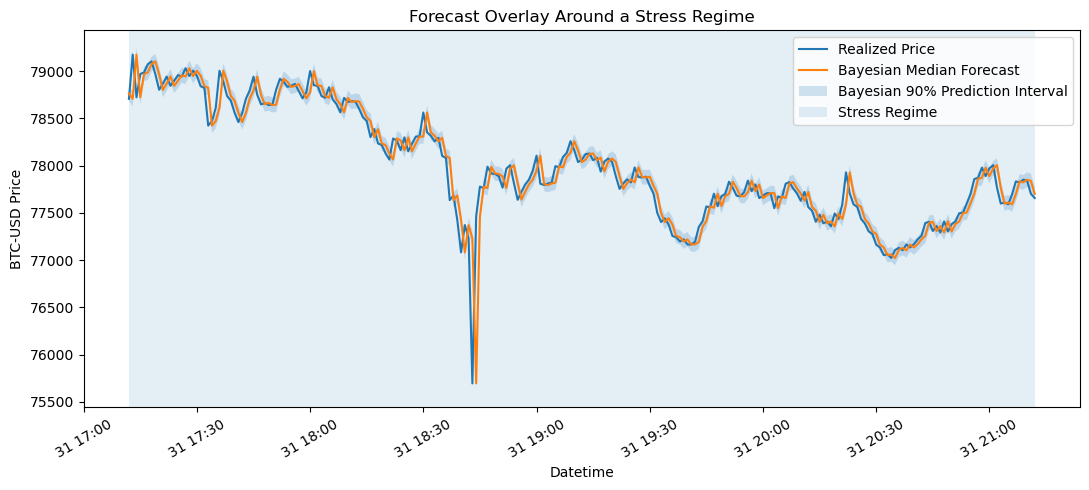

In [28]:
# 16C. Forecast Overlay During a Stress Window

# Pick a representative stress window centered on the highest rolling volatility point
plot_base_df = results_stress.dropna(subset=["roll_vol"]).copy()

if not plot_base_df.empty:
    peak_dt = plot_base_df["roll_vol"].idxmax()
    peak_loc = plot_base_df.index.get_loc(peak_dt)
    window_radius = 120  # roughly 4 hours total around the stress peak
    start_loc = max(0, peak_loc - window_radius)
    end_loc = min(len(plot_base_df), peak_loc + window_radius + 1)
    overlay_df = plot_base_df.iloc[start_loc:end_loc].copy()

    if SHOW_PLOTS:
        fig, ax = plt.subplots(figsize=(11, 5))
        ax.plot(overlay_df.index, overlay_df["S_t"], label="Realized Price")
        ax.plot(overlay_df.index, overlay_df["pred_median_bayes"], label="Bayesian Median Forecast")
        ax.fill_between(
            overlay_df.index,
            overlay_df["pi_low_bayes"],
            overlay_df["pi_high_bayes"],
            alpha=0.2,
            label="Bayesian 90% Prediction Interval"
        )

        stress_mask = overlay_df["is_stress"].fillna(False).astype(bool)
        if stress_mask.any():
            stress_blocks = []
            start = None
            prev = None
            for dt, is_stress in stress_mask.items():
                if is_stress and start is None:
                    start = dt
                if (not is_stress) and start is not None:
                    stress_blocks.append((start, prev))
                    start = None
                prev = dt
            if start is not None:
                stress_blocks.append((start, prev))

            for j, (a, b) in enumerate(stress_blocks):
                ax.axvspan(a, b, alpha=0.12, label="Stress Regime" if j == 0 else None)

        ax.set_title("Forecast Overlay Around a Stress Regime")
        ax.set_xlabel("Datetime")
        ax.set_ylabel("BTC-USD Price")
        ax.legend()
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()
else:
    overlay_df = pd.DataFrame()


The stress-window overlay visually shows failure. The realized prices move quickly, but the predictive model doesn’t widen fast enough to remain accurate. That gap is the coverage collapse shown in the table above. 
Looking at an average to determine model fit isn’t enough, and stress results matter. It shows that the model is overconfident during periods of highest uncertainty. 


### Figure 5 - _Prediction Interval Coverage by Market Regime_


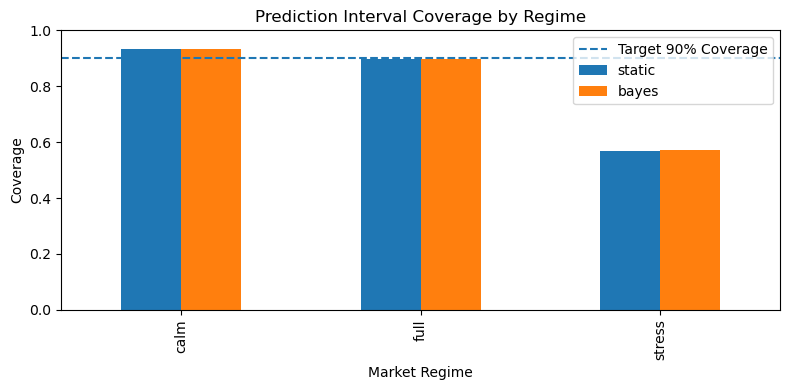

In [29]:
# 16D. Coverage by Market Regime

coverage_plot_df = stress_summary_df[["subset", "model", "coverage_90"]].copy()

# Optional ordering
subset_order = ["calm", "full", "stress"]
model_order = ["static", "bayes"]

coverage_plot_df["subset"] = pd.Categorical(
    coverage_plot_df["subset"],
    categories=subset_order,
    ordered=True
)
coverage_plot_df["model"] = pd.Categorical(
    coverage_plot_df["model"],
    categories=model_order,
    ordered=True
)

coverage_plot_df = coverage_plot_df.sort_values(["subset", "model"])

pivot_cov = coverage_plot_df.pivot(index="subset", columns="model", values="coverage_90")

if SHOW_PLOTS:
    ax = pivot_cov.plot(kind="bar", figsize=(8, 4))
    plt.axhline(0.90, linestyle="--", label="Target 90% Coverage")
    plt.title("Prediction Interval Coverage by Regime")
    plt.xlabel("Market Regime")
    plt.ylabel("Coverage")
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Discussion and Conclusion

In this comparison, neither model clearly outperforms the other. Adaptive volatility learning provides only marginal improvements, while both models remain overconfident during high-volatility periods.

The static model is simple and competitive. The Bayesian model is more complex and does show slightly better probabilistic metrics, but the gains are not large enough to address the core issue revealed by the stress analysis.

At its core, the problem is reactivity. The Bayesian model updates using past returns, so it adapts over time, but it can only react after volatility has already entered the data.

During abrupt regime shifts, this becomes a real limitation. One change is not enough to fully adjust the model, so it takes multiple steps to catch up.

What matters most in environments like this is not small improvements in average CRPS or similar metrics. The system needs to remain robust and correctly estimate uncertainty when the market becomes unstable.

This project does not show that Bayesian updating meaningfully outperforms a static baseline. It shows something more useful: adaptive updating helps slightly, but both models underestimate the tails of the distribution and break down under stress.

Understanding where models fail, and why, is critical in real-world settings. These results point toward future work on faster-reacting volatility models, as well as approaches that better capture volatility clustering and regime changes.

